# 02 — Preprocessing Pipeline

This notebook transforms noisy raw podcast JSONL data into a clean, semantically rich dataset ready for embeddings and FAISS retrieval.

## Objectives
- Build a stable, production-style preprocessing pipeline.
- Prioritize semantic quality over metadata completeness.
- Create a unified `combined_text` field for semantic search and retrieval.
- Export a full processed dataset and a 20k-record development subset.

## SECTION 1 — Imports + Paths

In [16]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import re

# Constants
RAW_DATA_DIR = Path("../data/raw")
PROCESSED_DATA_DIR = Path("../data/processed")
PODCASTS_FILE = RAW_DATA_DIR / "podcasts.json"
CATEGORIES_FILE = RAW_DATA_DIR / "categories.json"

# Ensure output directory exists
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raw data directory: {RAW_DATA_DIR.absolute()}")
print(f"Processed data directory: {PROCESSED_DATA_DIR.absolute()}")

Raw data directory: c:\Users\vaibh\ai_projects\podcast-mind\notebooks\..\data\raw
Processed data directory: c:\Users\vaibh\ai_projects\podcast-mind\notebooks\..\data\processed


## SECTION 2 — Build Category Lookup

We create a mapping from `podcast_id` to a list of categories to enrich the podcast records during streaming.

In [17]:
category_lookup = defaultdict(list)

with open(CATEGORIES_FILE, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc="Building category lookup"):
        try:
            record = json.loads(line)
            p_id = record.get('podcast_id')
            cat = record.get('category')
            if p_id and cat:
                category_lookup[p_id].append(cat)
        except json.JSONDecodeError:
            continue

print(f"Mapped categories for {len(category_lookup)} podcasts.")

Building category lookup: 0it [00:00, ?it/s]

Mapped categories for 2118882 podcasts.


## SECTION 3 — Filtering Configuration

We define strict requirements for semantic richness. Embeddings rely heavily on the descriptive quality of the text.

In [18]:
MIN_DESCRIPTION_LENGTH = 80
MIN_UNIQUE_WORDS = 15

# Patterns that often indicate low-value boilerplate or generic descriptions
SEMANTIC_WEAK_PATTERNS = [
    r"(?i)podcast by",
    r"(?i)welcome to my podcast",
    r"(?i)stories from",
    r"(?i)episodes of",
    r"(?i)official podcast",
    r"(?i)new podcast",
    r"(?i)listen to",
    r"(?i)subscribe to",
    r"(?i)follow us on",
]

def is_semantically_weak(text):
    """Checks if a text is semantically weak based on patterns and unique word count."""
    if not text:
        return True
    
    # Check unique word count
    words = re.findall(r'\w+', text.lower())
    if len(set(words)) < MIN_UNIQUE_WORDS:
        return True
    
    # Check weak patterns
    # Note: We only flag as weak if it *mostly* consists of these patterns, 
    # but for simplicity here we check if many appear or if text is very short.
    # For this implementation, we will just count hits.
    hits = sum(1 for pattern in SEMANTIC_WEAK_PATTERNS if re.search(pattern, text))
    if hits > 2: # Arbitrary threshold for "too much boilerplate"
        return True
        
    return False

## SECTION 4 — Stream + Filter Records

Processing records line-by-line to minimize memory footprint. We apply filters for existence of title/description and semantic richness.

In [19]:
processed_records = []
stats = {
    'total': 0,
    'missing_title_or_desc': 0,
    'too_short': 0,
    'semantically_weak': 0,
    'kept': 0
}

with open(PODCASTS_FILE, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc="Streaming podcasts"):
        stats['total'] += 1
        try:
            record = json.loads(line)
        except json.JSONDecodeError:
            continue
            
        title = record.get('title')
        description = record.get('description')
        
        # 1. Required Filters
        if not title or not description:
            stats['missing_title_or_desc'] += 1
            continue
            
        # 2. Length Filter
        if len(description) < MIN_DESCRIPTION_LENGTH:
            stats['too_short'] += 1
            continue
            
        # 3. Semantic Weakness Filter
        if is_semantically_weak(description):
            stats['semantically_weak'] += 1
            continue
            
        # Enrich with categories
        categories = category_lookup.get(record['podcast_id'], [])
        
        # Clean record
        clean_record = {
            'podcast_id': record['podcast_id'],
            'title': title.strip(),
            'author': (record.get('author') or "").strip(),
            'description': description.strip(),
            'categories': ", ".join(categories)
        }
        
        processed_records.append(clean_record)
        stats['kept'] += 1

print("\nStreaming complete.")
for k, v in stats.items():
    print(f"{k:25}: {v}")

Streaming podcasts: 0it [00:00, ?it/s]


Streaming complete.
total                    : 2077665
missing_title_or_desc    : 1927857
too_short                : 30523
semantically_weak        : 7453
kept                     : 111832


## SECTION 5 — Create DataFrame

In [20]:
df = pd.DataFrame(processed_records)
print(f"DataFrame created with {len(df)} rows.")
df.head()

DataFrame created with 111832 rows.


,podcast_id,title,author,description,categories
0,3cfef94cfccf27eb504bd7a6c7459636,OriginALL,CityPodcast,OriginALL este un show cu oameni inteligenti p...,"business-careers, business"
1,2f2205dcc248024b0a3be4665f38e33a,The Big Podcast With Shaq,PodcastOne,"Much bigger than sports, the show is fun, topi...",
2,9fc35a81647e391f93211b5d11973c83,Galaktacus,"Jim Kettner, John Mihaly, and Scott Brown",The name Galaktacus originates from a youthful...,tv-film
3,3fb94aea4c94c30f85b34a299d2da986,Sports From Her Perspective,Sports From Her Perspective,This will be a podcast of sports topics that d...,
4,aed410e50370beec62b241374abb296b,The Talking Pictures Podcast,Todd Mizener,Photojournalism on the radio...sort of. The ph...,"news, arts-visual-arts, arts"


## SECTION 6 — Semantic Density Scoring

We track "metadata richness" separately from semantic quality. This score helps us understand how much context we have for each record.

In [21]:
def calculate_density(row):
    score = 0
    if row['title']: score += 1
    if row['author']: score += 1
    if row['categories']: score += 1
    if row['description']: score += 1
    return score

df['semantic_density_score'] = df.apply(calculate_density, axis=1)
print("Semantic density distribution:")
print(df['semantic_density_score'].value_counts().sort_index())

Semantic density distribution:
semantic_density_score
3      8992
4    102840
Name: count, dtype: int64


## SECTION 7 — Create combined_text

This is the most critical field. It aggregates all semantic signals into a single string for embedding.

In [22]:
def build_combined_text(row):
    parts = []
    if row['title']:
        parts.append(f"Title: {row['title']}")
    if row['author']:
        parts.append(f"Author: {row['author']}")
    if row['categories']:
        parts.append(f"Categories: {row['categories']}")
    if row['description']:
        parts.append(f"Description: {row['description']}")
    
    return " | ".join(parts)

df['combined_text'] = df.apply(build_combined_text, axis=1)

# Null safety check
assert df['combined_text'].isna().sum() == 0, "Found NaN in combined_text"
assert (df['combined_text'] == "").sum() == 0, "Found empty strings in combined_text"

print("Sample combined_text:")
print(df['combined_text'].iloc[0][:200] + "...")

Sample combined_text:
Title: OriginALL | Author: CityPodcast | Categories: business-careers, business | Description: OriginALL este un show cu oameni inteligenti pe care vrei sa-i asculti pentru ca ei sunt cei care schimba...


## SECTION 8 — Remove Duplicates

Duplicates introduce noise and bias in retrieval results.

In [23]:
initial_count = len(df)
df = df.drop_duplicates(subset=['combined_text'])
removed = initial_count - len(df)
print(f"Removed {removed} duplicate records. Final count: {len(df)}.")

Removed 9 duplicate records. Final count: 111823.


## SECTION 9 — Final Validation

In [24]:
print("--- Data Quality Check ---")
print(f"Null values:\n{df.isnull().sum()}")
print(f"\nCategory coverage: {(df['categories'] != '').mean():.2%}")
print(f"Author coverage: {(df['author'] != '').mean():.2%}")

print("\n--- Description Length Stats ---")
print(df['description'].str.len().describe())

print("\n--- Random Inspection Samples ---")
for text in df['combined_text'].sample(3, random_state=42):
    print(f"\n{'-'*50}\n{text[:500]}...")

--- Data Quality Check ---
Null values:
podcast_id                0
title                     0
author                    0
description               0
categories                0
semantic_density_score    0
combined_text             0
dtype: int64

Category coverage: 91.96%
Author coverage: 100.00%

--- Description Length Stats ---
count    111823.000000
mean        351.423857
std         299.710677
min          80.000000
25%         166.000000
50%         263.000000
75%         430.000000
max        3897.000000
Name: description, dtype: float64

--- Random Inspection Samples ---

--------------------------------------------------
Title: Chinwag Live Podcasts | Author: Chinwag Live | Categories: business, technology | Description: Chinwag is an online community for digital professionals and Chinwag live is our regular events series established to cast light on trends across the digital media industry....

--------------------------------------------------
Title: Agora Historia Oficial

## SECTION 10 — Dataset Quality Reporting

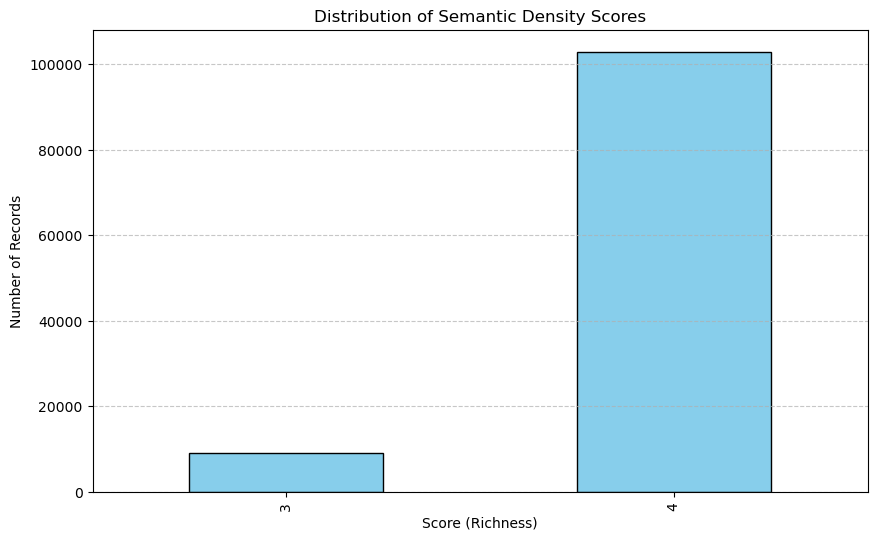

Final Dataset Size: 111823


In [25]:
plt.figure(figsize=(10, 6))
df['semantic_density_score'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribution of Semantic Density Scores")
plt.xlabel("Score (Richness)")
plt.ylabel("Number of Records")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Final Dataset Size: {len(df)}")

## SECTION 11 — Export Final Dataset

In [26]:
output_path = PROCESSED_DATA_DIR / "podcasts_subset.csv"
df.to_csv(output_path, index=False)
print(f"Saved full dataset to: {output_path}")

Saved full dataset to: ..\data\processed\podcasts_subset.csv


## SECTION 12 — Create Development Subset

A 20k record sample for fast iteration during model development.

In [27]:
df_20k = df.sample(min(20000, len(df)), random_state=42)
subset_path = PROCESSED_DATA_DIR / "podcasts_subset_20k.csv"
df_20k.to_csv(subset_path, index=False)
print(f"Saved 20k subset to: {subset_path}")

Saved 20k subset to: ..\data\processed\podcasts_subset_20k.csv
